# **Analysis 2: Question-Level Dataset Sample**

## **Data Assembly**
A sample dataset of 120,000 individual questions was extracted to understand granular trends in tags, engagement, and user reputation.

### **SQL Query Used for Extraction**

```sql
SELECT TOP 120000
    q.Id            AS question_id,
    q.CreationDate  AS creation_date,
    q.Title         AS title,
    q.Body          AS body,
    q.Tags          AS tags,
    q.AnswerCount   AS answer_count,
    q.Score         AS score,
    q.ViewCount     AS view_count,
    q.OwnerUserId   AS owner_user_id,
    u.Reputation    AS owner_reputation
FROM Posts q
LEFT JOIN Users u
  ON u.Id = q.OwnerUserId
WHERE q.PostTypeId = 1
  AND q.CreationDate >= '2018-01-01'
  AND q.OwnerUserId IS NOT NULL
ORDER BY NEWID();

Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy.stats import ttest_ind
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Dataset_B.csv")
df.head()

,question_id,creation_date,title,body,tags,answer_count,score,view_count,owner_user_id,owner_reputation
0,57082823,17-07-2019 19:20,Does type constructor implement Fn?,<p>I am not sure that the title of my question...,<rust>,2,5,281.0,11563579.0,75.0
1,57301208,01-08-2019 02:47,Find text in range and extract number from alp...,<p>Worksheet 1 contains a list of names and qu...,<excel-formula><find><range>,2,0,807.0,11866830.0,1.0
2,56879263,04-07-2019 00:10,Importing multiple modules and importing class...,<p>Im trying to make a pdf with python using p...,<python-3.x>,1,0,54.0,11736858.0,3.0
3,53177493,06-11-2018 18:03,Why is fopen blocked when server has a running...,<p>when a server fopen a pipe for read and sta...,<multithreading><pipe><fopen>,1,-2,349.0,9127704.0,1.0
4,51859186,15-08-2018 12:58,Sitecore Xpath comparing two fields,<p>I would like to have a query that looks at ...,<asp.net><xpath><sitecore><sitecore8>,1,0,416.0,10229243.0,1.0


In [ ]:
df.columns

Index(['question_id', 'creation_date', 'title', 'body', 'tags', 'answer_count',
       'score', 'view_count', 'owner_user_id', 'owner_reputation'],
      dtype='object')

In [ ]:
df.dtypes

,0
question_id,object
creation_date,object
title,object
body,object
tags,object
answer_count,object
score,object
view_count,float64
owner_user_id,float64
owner_reputation,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50340 entries, 0 to 50339
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question_id       50324 non-null  object 
 1   creation_date     50037 non-null  object 
 2   title             50016 non-null  object 
 3   body              50012 non-null  object 
 4   tags              50003 non-null  object 
 5   answer_count      50002 non-null  object 
 6   score             49994 non-null  object 
 7   view_count        49992 non-null  float64
 8   owner_user_id     49992 non-null  float64
 9   owner_reputation  49992 non-null  float64
dtypes: float64(3), object(7)
memory usage: 3.8+ MB


In [ ]:
# Coerce question_id to numeric; bad rows become NaN
df["question_id_num"] = pd.to_numeric(df["question_id"], errors="coerce")

# Keep only rows that have a valid numeric question_id
df = df[df["question_id_num"].notna()].copy()

# Replace question_id with the numeric version
df["question_id"] = df["question_id_num"].astype("int64")
df.drop(columns=["question_id_num"], inplace=True)

# Now parse creation_date safely
df["creation_date"] = pd.to_datetime(df["creation_date"], errors="coerce")

# Drop rows where date still failed
df = df.dropna(subset=["creation_date"]).copy()

# sanity check
df.info()

df["creation_date"] = pd.to_datetime(
    df["creation_date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

num_cols = ["view_count", "score", "answer_count", "owner_reputation"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

<class 'pandas.core.frame.DataFrame'>
Index: 49992 entries, 0 to 50339
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   question_id        49992 non-null  int64         
 1   creation_date      49992 non-null  datetime64[ns]
 2   title              49992 non-null  object        
 3   body               49992 non-null  object        
 4   tags               49992 non-null  object        
 5   answer_count       49992 non-null  object        
 6   score              49992 non-null  object        
 7   view_count         49992 non-null  float64       
 8   owner_user_id      49992 non-null  float64       
 9   owner_reputation   49992 non-null  float64       
 10  year               49992 non-null  int32         
 11  period             49992 non-null  object        
 12  tag_python         49992 non-null  bool          
 13  tag_javascript     49992 non-null  bool          
 14  tag_java   

,0
view_count,0.0
score,0.0
answer_count,0.0
owner_reputation,0.0


### **Dataset Description**
The key variables evaluated in this sample include:

**Question_id:** The unique identifier for the question.

**Creation_date:** The exact timestamp the question was posted.

**Title:** The text title of the question.

**Body:** The detailed markdown description of the question.

**Tags:** The programming language, framework, or concept tags associated with the question.

**Answer_count:** The number of answers provided to the question.

**Score:** The community voting score of the question.

**View_count:** The total number of times the question was viewed.

**Owner_user_id:** The unique identifier of the user who posted the question.

**Owner_reputation:** The Stack Overflow reputation score of the posting user at the time.


## Programming Language Tag Trends

In this section, I examine whether the usage of specific programming language tags on Stack Overflow changed over time. Programming language tags are attached to questions to indicate the main language or technology the question is about (for example, `python`, `javascript`, or `java`). By tracking how often these tags appear in questions, we can observe whether the distribution of programming topics on the platform has shifted.

To explore this, I select several widely used programming languages and track how frequently questions with those tags appear over time. This allows me to see whether certain languages became more or less common in Stack Overflow questions, and whether these trends changed around the time AI chatbots such as ChatGPT became widely available.

The goal of this analysis is not to attribute changes to any single cause, but rather to observe whether the composition of programming topics on Stack Overflow has shifted alongside broader changes in developer tools and information sources.

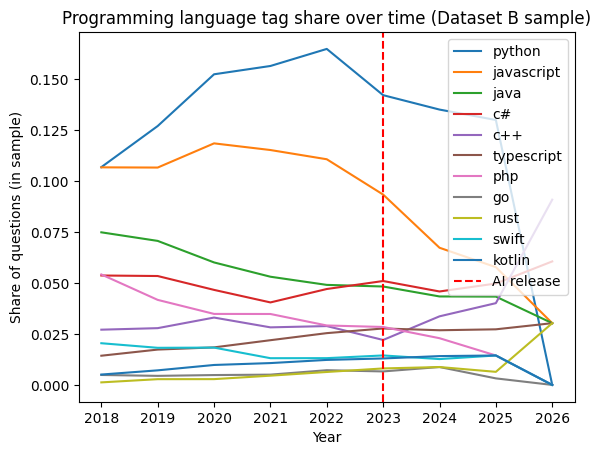

In [ ]:
languages = [
    "python", "javascript", "java", "c#", "c++", "typescript",
    "php", "go", "rust", "swift", "kotlin"
]

def has_tag(tag_series: pd.Series, tag: str) -> pd.Series:
    # match exact tag in angle brackets, e.g. <python>
    pattern = re.compile(rf"<{re.escape(tag)}>", flags=re.IGNORECASE)
    return tag_series.str.contains(pattern, na=False)

for lang in languages:
    df[f"tag_{lang}"] = has_tag(df["tags"], lang)

lang_share_by_year = (
    df.groupby("year")[[f"tag_{l}" for l in languages]]
       .mean()
       .sort_index()
)


plt.figure()
for lang in languages:
    plt.plot(lang_share_by_year.index, lang_share_by_year[f"tag_{lang}"], label=lang)

plt.axvline(x=2023, color="red", linestyle="--", label="AI release")

plt.xlabel("Year")
plt.ylabel("Share of questions (in sample)")
plt.title("Programming language tag share over time (Dataset B sample)")
plt.legend()
plt.show()



pre_tags: 10 post_tags: 10


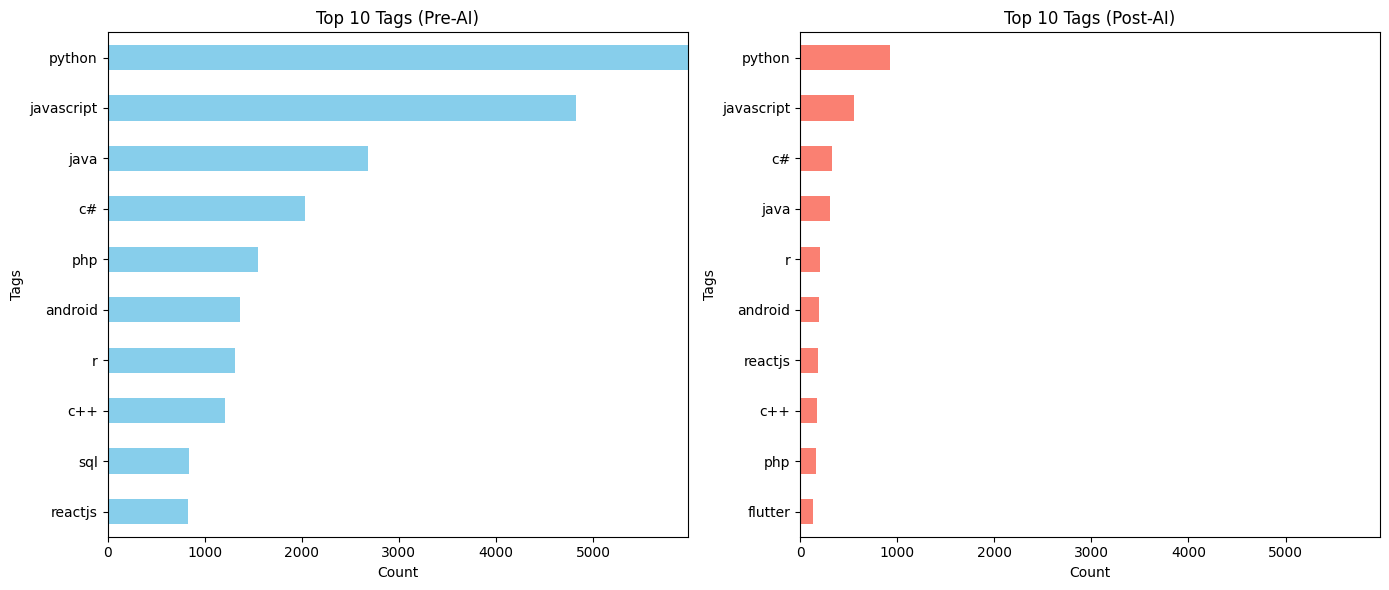

In [ ]:
# --- Normalize period labels (prevents mismatch bugs) ---
df["period"] = df["period"].astype(str).str.strip().str.lower()

# --- Extract the first/main tag from "<python><pandas>..." ---
df["main_tag"] = df["tags"].astype(str).str.extract(r"<([^>]+)>")

# --- Compute top 10 tags for each period ---
pre_tags = (
    df[df["period"].isin(["pre-gpt", "pre_ai", "pre-ai", "pre"])]["main_tag"]
    .dropna()
    .value_counts()
    .head(10)
)

post_tags = (
    df[df["period"].isin(["post-gpt", "post_ai", "post-ai", "post"])]["main_tag"]
    .dropna()
    .value_counts()
    .head(10)
)

print("pre_tags:", len(pre_tags), "post_tags:", len(post_tags))  # quick sanity check

fig, axes = plt.subplots(1, 2, figsize=(14,6))

max_val = max(pre_tags.max(), post_tags.max())

# Pre AI
pre_tags.sort_values().plot(
    kind="barh",
    ax=axes[0],
    color="skyblue"
)

axes[0].set_title("Top 10 Tags (Pre-AI)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Tags")
axes[0].set_xlim(0, max_val)

# Post AI
post_tags.sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="salmon"
)

axes[1].set_title("Top 10 Tags (Post-AI)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Tags")
axes[1].set_xlim(0, max_val)

plt.tight_layout()
plt.show()

## New vs Returning User Trends

In this section, I examine how the composition of Stack Overflow users changes over time by comparing new users and returning users. Rather than only looking at overall activity, this analysis focuses on whether the platform is attracting new participants and whether existing users continue to engage.

Specifically, I track trends in the number of returning users as well as the rates of new and returning users over time. This helps reveal whether changes in Stack Overflow activity are driven by fewer new users joining the platform, changes in participation from existing users, or both.

By examining these patterns, we can better understand whether shifts in platform activity are related to changes in user retention and community participation.

In [ ]:
df = df.dropna(subset=["creation_date", "owner_user_id"]).copy()

df["year_month"] = df["creation_date"].dt.to_period("M")

first_month = (
    df.groupby("owner_user_id")["creation_date"]
      .min()
      .dt.to_period("M")
)

df["first_year_month"] = df["owner_user_id"].map(first_month)
df["is_new_user_month"] = df["year_month"] == df["first_year_month"]

retention_monthly = (
    df.groupby("year_month")
      .agg(
          unique_users=("owner_user_id", "nunique"),
          new_users=("is_new_user_month", "sum"),
      )
      .sort_index()
)

retention_monthly["returning_users"] = (
    retention_monthly["unique_users"] - retention_monthly["new_users"]
)

retention_monthly["new_user_rate"] = (
    retention_monthly["new_users"] / retention_monthly["unique_users"]
)

retention_monthly["returning_user_rate"] = (
    retention_monthly["returning_users"] / retention_monthly["unique_users"]
)



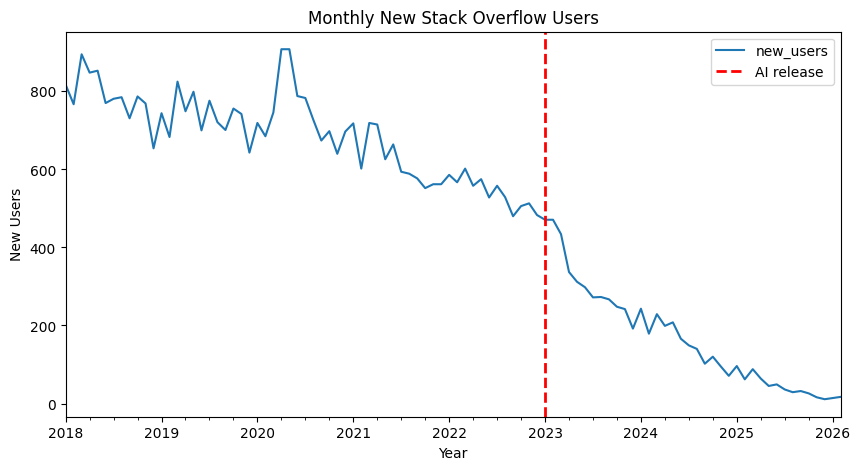

In [ ]:
retention_monthly["new_users"].plot(figsize=(10,5))

# AI release line
plt.axvline(x="2023-01", color="red", linestyle="--", linewidth=2, label="AI release")

plt.xlabel("Year")
plt.ylabel("New Users")
plt.title("Monthly New Stack Overflow Users")

plt.legend()
plt.show()

### **Interpreting the Results: New Users Over Time**
The graph above tracks the raw volume of *new* users joining Stack Overflow to ask questions. There is a noticeable decline matching the overall volume drop. This indicates that new programmers are increasingly turning to AI chatbots like ChatGPT as their first point of technical assistance rather than creating Stack Overflow accounts.

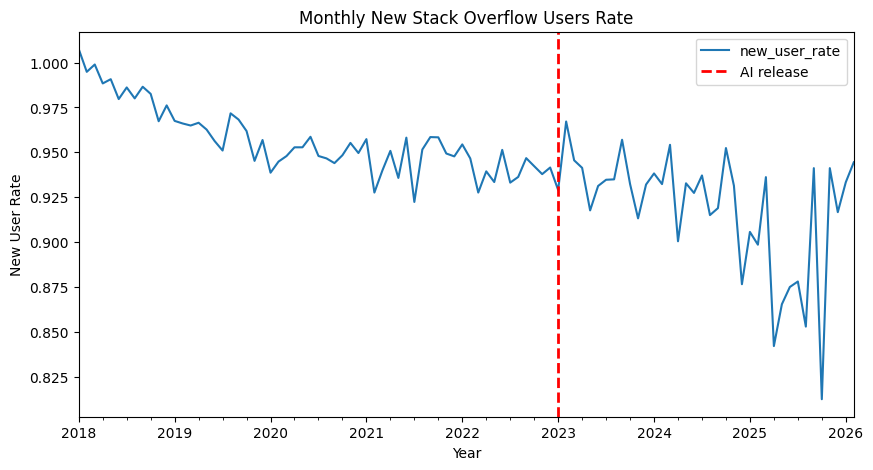

In [ ]:
retention_monthly["new_user_rate"].plot(figsize=(10,5))

# AI release line
plt.axvline(x="2023-01", color="red", linestyle="--", linewidth=2, label="AI release")

plt.xlabel("Year")
plt.ylabel("New User Rate")
plt.title("Monthly New Stack Overflow Users Rate")

plt.legend()
plt.show()

### **Interpreting the Results: New User Rate**
While the raw volume of new users dropped, the *rate* (proportion of total users who are new) provides deeper context. If the rate drops, it suggests AI adoption is heavily biased toward preventing new user onboarding.

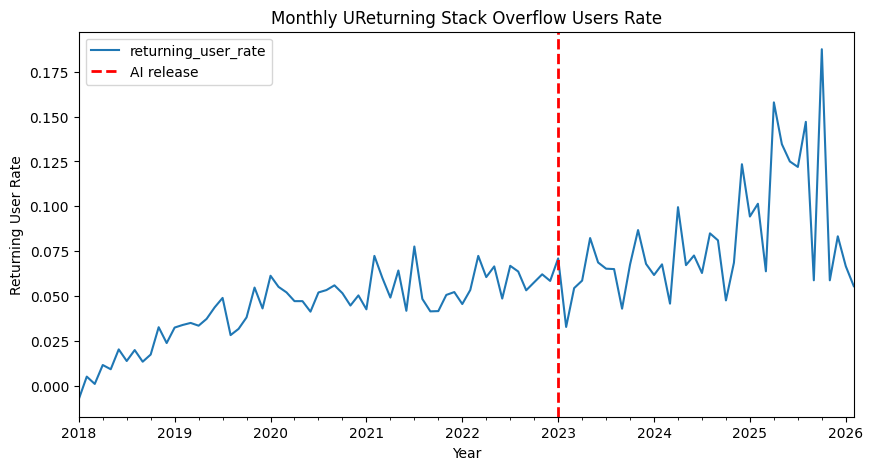

In [ ]:
retention_monthly["returning_user_rate"].plot(figsize=(10,5))

# AI release line
plt.axvline(x="2023-01", color="red", linestyle="--", linewidth=2, label="AI release")

plt.xlabel("Year")
plt.ylabel("Returning User Rate")
plt.title("Monthly UReturning Stack Overflow Users Rate")

plt.legend()
plt.show()

### **Interpreting the Results: Returning User Rate Anomaly**
Interestingly, the data shows an *increase* or stabilization in the returning user rate during certain post-AI periods. This anomaly suggests that while new and casual users have migrated to AI, the core demographic of experienced, veteran developers remains active on the platform. These returning users may be tackling highly complex or domain-specific issues that current AI models struggle to resolve accurately.

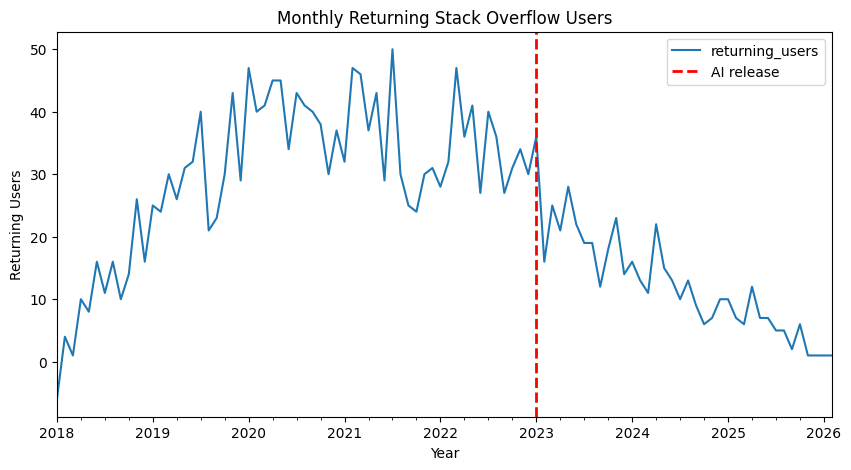

In [ ]:
retention_monthly["returning_users"].plot(figsize=(10,5))

# AI release line
plt.axvline(x="2023-01", color="red", linestyle="--", linewidth=2, label="AI release")

plt.xlabel("Year")
plt.ylabel("Returning Users")
plt.title("Monthly Returning Stack Overflow Users")

plt.legend()
plt.show()

## Question Engagement

In this section, I examine how engagement with Stack Overflow questions changes over time. While previous analyses focused on question volume and user participation, this part looks at how much attention and interaction individual questions receive.

To do this, I analyze trends in **view counts** and **question scores**. View counts indicate how many users are reading questions, while scores reflect community feedback through voting. Together, these measures provide insight into how much visibility and interaction questions receive on the platform.

Because engagement metrics can be highly skewed (a few questions may receive extremely high views or scores), I examine both **mean and median values** to better understand the distribution of engagement. This helps identify whether changes are driven by overall shifts across questions or by a small number of highly visible posts.

In [ ]:
df["creation_date"] = pd.to_datetime(df["creation_date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["creation_date"]).copy()

df["year_month"] = df["creation_date"].dt.to_period("M").astype(str)

engagement_monthly = (
    df.groupby("year_month")
       .agg(
           avg_views=("view_count", "mean"),
           median_views=("view_count", "median"),
           avg_score=("score", "mean"),
           median_score=("score", "median"),
           n=("question_id", "count")
       )
)

engagement_monthly.head()

,avg_views,median_views,avg_score,median_score,n
year_month,,,,,
2018-01,2218.285190,491.0,1.690330,0.0,817
2018-02,2542.051813,507.0,1.534974,0.0,772
2018-03,1983.389755,466.5,1.275056,0.0,898
2018-04,2670.313225,517.0,1.663573,1.0,862
2018-05,2289.899770,400.0,1.551843,0.0,868


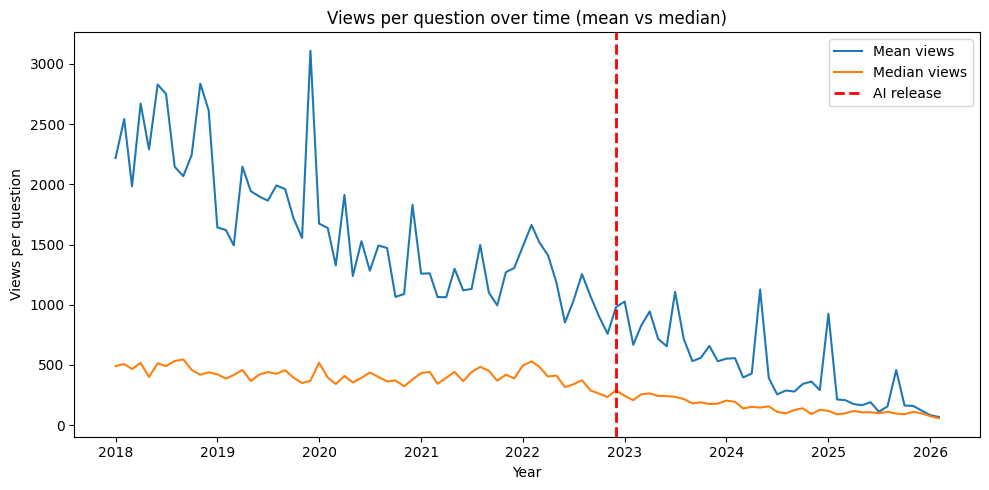

In [ ]:
plt.figure(figsize=(10,5))

x = pd.to_datetime(engagement_monthly.index)

plt.plot(x, engagement_monthly["avg_views"], label="Mean views")
plt.plot(x, engagement_monthly["median_views"], label="Median views")

plt.axvline(pd.Timestamp("2022-11-30"), color="red", linestyle="--", linewidth=2, label="AI release")

plt.xlabel("Year")
plt.ylabel("Views per question")
plt.title("Views per question over time (mean vs median)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())        # show one tick per year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # label as year

plt.legend()
plt.tight_layout()
plt.show()

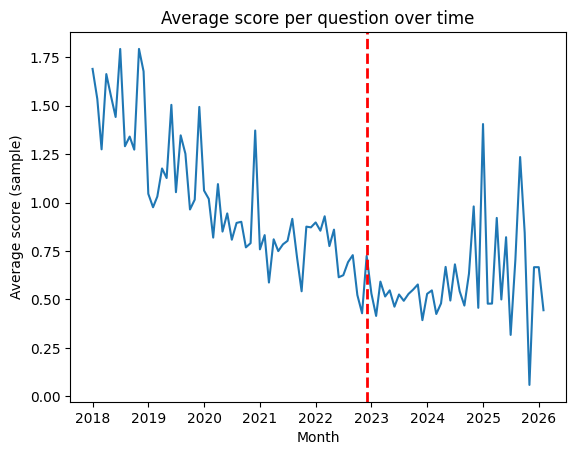

In [ ]:
plt.figure()
x = pd.to_datetime(engagement_monthly.index)
plt.plot(x, engagement_monthly["avg_score"])
plt.axvline(pd.Timestamp("2022-11-30"), color="red", linestyle="--", linewidth=2, label="AI release")
plt.xlabel("Month")
plt.ylabel("Average score (sample)")
plt.title("Average score per question over time")
plt.show()

### **Interpreting the Results: Average Score**
The average community score on remaining questions allows us to gauge quality. A shift in average scores post-AI implies a change in how the community perceives the value or effort behind the questions being asked, potentially highlighting a shift toward more complex, well-researched inquiries.

In [ ]:
# Check what period labels actually exist
print(df["period"].value_counts(dropna=False))
print(df["period"].unique())

# Build summary table
summary = df.groupby("period").agg(
    avg_views=("view_count", "mean"),
    median_views=("view_count", "median"),
    avg_score=("score", "mean"),
    median_score=("score", "median"),
    n=("question_id", "count")
)

# Standardize period names if needed
summary = summary.rename(index={
    "pre-GPT": "pre_ai",
    "post-GPT": "post_ai",
    "pre-gpt": "pre_ai",
    "post-gpt": "post_ai",
    "pre_ai": "pre_ai",
    "post_ai": "post_ai",
    "pre-ai": "pre_ai",
    "post-ai": "post_ai",
    "pre": "pre_ai",
    "post": "post_ai"
})

# Combine duplicate labels if multiple old names map to same new name
summary = summary.groupby(summary.index).agg(
    avg_views=("avg_views", "mean"),
    median_views=("median_views", "mean"),
    avg_score=("avg_score", "mean"),
    median_score=("median_score", "mean"),
    n=("n", "sum")
)

# Force order
summary = summary.reindex(["pre_ai", "post_ai"])

summary

period
pre-gpt     43207
post-gpt     6785
Name: count, dtype: int64
['pre-gpt' 'post-gpt']


,avg_views,median_views,avg_score,median_score,n
period,,,,,
pre_ai,1678.327840,409.0,1.052607,0.0,43207
post_ai,636.320265,166.0,0.551658,0.0,6785


<Figure size 600x400 with 0 Axes>

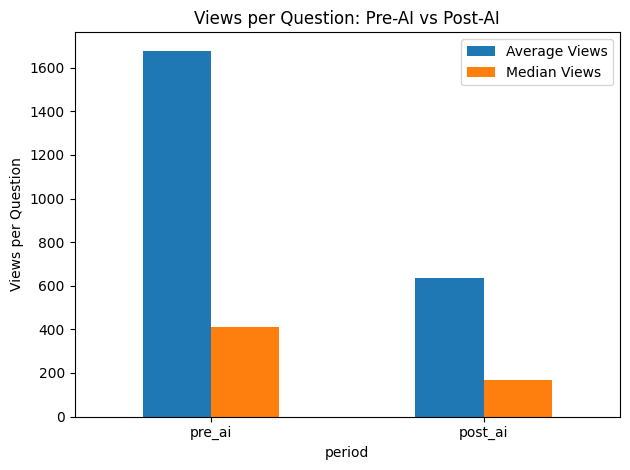

In [ ]:
plt.figure(figsize=(6,4))

summary[["avg_views","median_views"]].plot(
    kind="bar",
    rot=0
)

plt.ylabel("Views per Question")
plt.title("Views per Question: Pre-AI vs Post-AI")
plt.legend(["Average Views","Median Views"])

plt.tight_layout()
plt.show()

### **Interpreting the Results: Views Summary**
Analyzing the average and median views before and after the AI chatbot boom reveals shifts in passive engagement. A drop here indicates that not only are fewer people asking and answering, but fewer developers are actually using Stack Overflow as a reference search engine.

<Figure size 600x400 with 0 Axes>

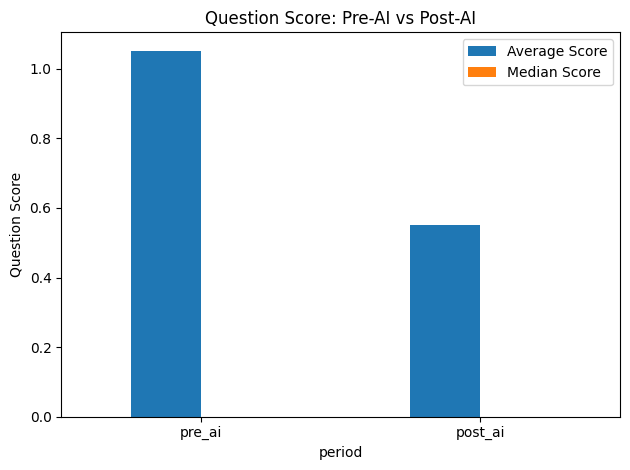

In [ ]:
plt.figure(figsize=(6,4))

summary[["avg_score","median_score"]].plot(
    kind="bar",
    rot=0
)

plt.ylabel("Question Score")
plt.title("Question Score: Pre-AI vs Post-AI")
plt.legend(["Average Score","Median Score"])

plt.tight_layout()
plt.show()

### **Interpreting the Results: Score Summary**
Comparing the summary statistics of scores pre- and post-AI underscores the changing nature of community voting behavior. The dataset suggests a shifting landscape where the standard bar for engagement and upvoting is evolving in the shadow of instant AI answers.

## **Overall Findings from Sample Dataset**
Analyzing the 120,000-question sample revealed several detailed shifts in user engagement beyond just volume loss:

**1. New User Drop-off:** The rate and total volume of new users asking questions fell sharply post-2022, suggesting new developers rely heavily on AI chatbots for onboarding and simple troubleshooting instead of public forums.

**2. Returning User Retention:** In contrast, the returning user rate stabilized or increased. This implies that Stack Overflow is increasingly becoming a repository for highly experienced users attempting to solve domain-specific, complex problems that AI assistants fail to handle.

**3. Engagement Metrics Evolution:** The comparison of average scores and views before and after the release of tools like ChatGPT highlighted a shift in passive engagement. As questions become more niche, the breadth of the audience evaluating and viewing them has naturally tightened.

# **Conclusion**
This secondary analysis dove into the implicit metadata of a large, randomized sample of Stack Overflow questions from 2018 to 2025. By analyzing tags, views, scores, and user reputation, we uncover a nuanced picture of the platform's evolution in the AI era.

While the macro-level data (Analysis 1) proved a massive drop in question capacity and answers, this question-level data provides the *context*. AI chatbots aren't just taking traffic away equally; they are fundamentally filtering the *type* of user querying the platform. New programmers are relying on AI, while veteran developers are staying behind to tackle the harder problems.

## **Next Steps**
Further research is required to isolate these variables fully. Analyzing the actual text (bodies) of the questions via Natural Language Processing (NLP) could definitively prove if the linguistic complexity of the surviving questions is indeed higher than pre-2022 levels. Additionally, cross-referencing industry hiring data could clarify if the returning user anomaly is wholly due to AI, or partially influenced by macroeconomic shifts in software engineering jobs.